# Поляризационный анализ и трансформация 3C-данных

При работе с трёхкомпонентыми данными (ВСП, 3D-3C) практически всегда возникает необходимость поляризационного анализа и правильной ориентировки данных. Это обусловлено тем, что:

1. **Ориентация геофонов может быть неточной** — в реальных условиях геофоны могут быть установлены с отклонениями от идеальной ориентации (X-East, Y-North, Z-Vertical).

2. **Поляризация волн содержит информацию о направлении распространения** — P-волны поляризованы вдоль направления распространения, S-волны — перпендикулярно.

3. **Необходимость разделения волн** — правильная трансформация в систему координат, связанную с направлением распространения (PRT/LQT), позволяет эффективно разделять P- и S-волны.

Рассмотрим случай ВСП.

Поляризацию волны определяют по прямой волне (по сути, первые вступления), так как она всегда поляризована вдоль луча (вдоль распространения фронта волны). 

Для P-волны вектор поляризации $\mathbf{P}$ совпадает с направлением распространения:

$$\mathbf{P} = \begin{pmatrix} P_x \\ P_y \\ P_z \end{pmatrix} = \begin{pmatrix} \sin\theta \sin\phi \\ \sin\theta \cos\phi \\ \cos\theta \end{pmatrix}$$

где $\theta$ — угол падения (incidence angle), $\phi$ — азимут (azimuth angle). 

<b>В этом ноутбуке на простом примере единичного события (совмещенный импульс P и SV волн) разсммотрим поляризационный анализ и поворот XYZ -> PRT</b>

План работы:
1. Создадим синтетические данные
2. Проведем поляризационный анализ
3. Повернем данные в PRT-систему координат
4. Проанализируем результаты



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from warnings import filterwarnings

### 1. Создание синтетических данных

Функция создания 3-компонентной синтетической записи единичного импульса сейсмического события (P+SV волны), падающего на приемник с заданным азимутом и углом падения.

Для генерации синтетических данных используются следующие соотношения:

**Направляющий вектор P-волны:**
$$\mathbf{n}_P = \begin{pmatrix} n_x \\ n_y \\ n_z \end{pmatrix} = \begin{pmatrix} \sin\theta \sin\phi \\ \sin\theta \cos\phi \\ \cos\theta \end{pmatrix}$$

где:
- $\theta$ — угол падения (incidence angle) от вертикали
- $\phi$ — азимут (azimuth angle) от направления на север

**Компоненты P-волны:**
$$\begin{pmatrix} P_x \\ P_y \\ P_z \end{pmatrix} = w_P(t) \cdot \mathbf{n}_P$$

где $w_P(t)$ — вейвлет P-волны (Ricker wavelet).

**Компоненты S-волны:**
S-волна поляризована перпендикулярно направлению распространения (SV-поляризация). В простейшем случае:
$$\begin{pmatrix} S_x \\ S_y \\ S_z \end{pmatrix} = w_S(t - \tau_S) \cdot \mathbf{n}_S$$

где $\mathbf{n}_S$ — единичный вектор, ортогональный $\mathbf{n}_P$, а $\tau_S$ — задержка S-волны относительно P-волны.

Функция для визуализации трёхкомпонентных данных.

Функция отображает три компоненты данных на одном графике с вертикальным смещением для удобства сравнения. Каждая компонента смещается на фиксированное значение для визуального разделения. 

In [2]:
def plot_analysis(t, comp1, comp2, comp3, names=None, title=None):
    """
    Универсальная функция для визуализации трех компонент.
    
    Parameters:
    -----------
    t : array
        Временная ось
    comp1, comp2, comp3 : array
        Три компоненты данных
    names : list of str, optional
        Список из трех строк для названий компонент (по умолчанию ['Comp1', 'Comp2', 'Comp3'])
    title : str, optional
        Общий заголовок графика
    """
    if names is None:
        names = ['Comp1', 'Comp2', 'Comp3']
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Графики трасс (Waveforms)
    ax.plot(t, comp1 + 2, 'k', label=names[0], linewidth=1.5)
    ax.plot(t, comp2 + 0, 'b', label=names[1], linewidth=1.5)
    ax.plot(t, comp3 - 2, 'r', label=names[2], linewidth=1.5)
    
    if title:
        ax.set_title(title)
    
    ax.set_xlabel("Время (с)")
    ax.set_yticks([2, 0, -2])
    ax.set_yticklabels(names)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper right', fontsize=9)
    
    plt.tight_layout()
    plt.show()

Итак, создаем имитацию регистрации единичного события (P-волна + смещенная SV-волна) 3-х компонентным приемником при наклонном падении волн

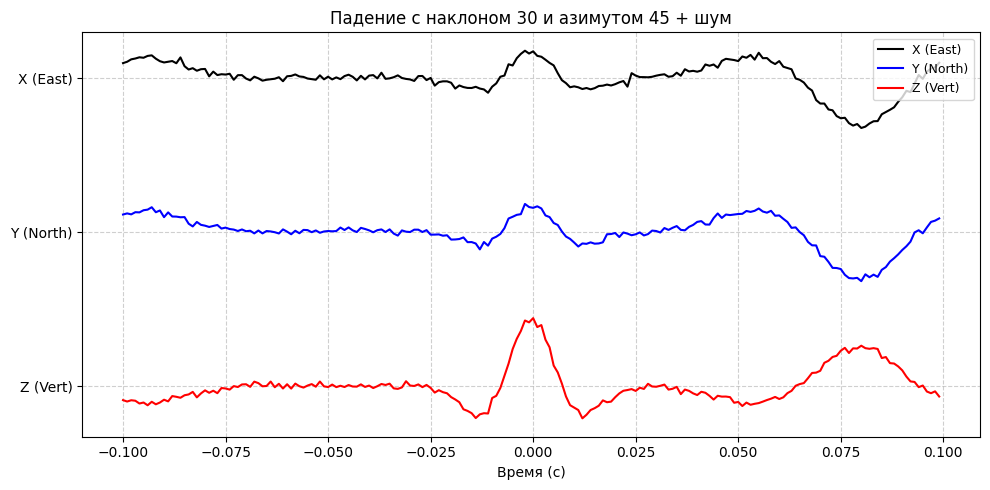

In [3]:
### Создание синтетических 3C-данных

# Параметры
true_az = 45  # Азимут в градусах
true_inc = 30  # Угол падения в градусах
s_delay = 0.08  # Задержка S-волны относительно P-волны (сек)
noise_lvl = 0.025  # Уровень шума

# --- 1. Временная ось ---
dt = 0.001
t = np.arange(-0.1, 0.1, dt)
n_samples = len(t)

# --- 2. Генерация Ricker вейвлетов ---
# P-волна (высокая частота, f=30 Гц)
length = 0.1
t0_p = np.linspace(-length/2, length/2, int(length/dt))
wp = (1.0 - 2.0*(np.pi*30*t0_p)**2) * np.exp(-(np.pi*30*t0_p)**2)

# S-волна (низкая частота, f=15 Гц)
t0_s = np.linspace(-length/2, length/2, int(length/dt))
ws = (1.0 - 2.0*(np.pi*15*t0_s)**2) * np.exp(-(np.pi*15*t0_s)**2)

# --- 3. Центрирование вейвлетов в массиве ---
# P-вейвлет
wp_padded = np.zeros(n_samples)
start_p = (n_samples - len(wp)) // 2
wp_padded[start_p:start_p + len(wp)] = wp

# S-вейвлет
ws_padded = np.zeros(n_samples)
start_s = (n_samples - len(ws)) // 2
ws_padded[start_s:start_s + len(ws)] = ws

# --- 4. Углы → направляющий вектор P ---
az = np.radians(true_az)
inc = np.radians(true_inc)

# Единичный вектор направления прихода P-волны (от источника к приёмнику)
P_vec_synth = np.array([
    np.sin(inc) * np.sin(az),   # X (East)
    np.sin(inc) * np.cos(az),   # Y (North)
    np.cos(inc)                  # Z (вниз положительный, как обычно в сейсмике)
])

# --- 5. P-волна (смещение вдоль P_vec) ---
Px = wp_padded * P_vec_synth[0]
Py = wp_padded * P_vec_synth[1]
Pz = wp_padded * P_vec_synth[2]

# --- 6. SV-волна (ортогональна P и лежит в вертикальной плоскости) ---
vertical = np.array([0.0, 0.0, 1.0])

# Вектор SV: перпендикулярен P и лежит в вертикальной плоскости падения
SV_vec = np.cross(P_vec_synth, vertical)   # лежит в плоскости падения
SV_vec = np.cross(SV_vec, P_vec_synth)     # строго ортогонален P
SV_vec /= np.linalg.norm(SV_vec)           # нормализуем

# Задержанная S-волна
shift_samples = int(round(s_delay / dt))
ws_delayed = np.roll(ws_padded, shift_samples)

Sx = ws_delayed * SV_vec[0]
Sy = ws_delayed * SV_vec[1]
Sz = ws_delayed * SV_vec[2]

# --- 7. Суммирование P и S волн ---
x = Px + Sx
y = Py + Sy
z = Pz + Sz

# --- 8. Добавление шума ---
if noise_lvl > 0.0:
    np.random.seed()  # чтобы каждый раз было по-разному
    x += np.random.normal(0, noise_lvl, n_samples)
    y += np.random.normal(0, noise_lvl, n_samples)
    z += np.random.normal(0, noise_lvl, n_samples)

# Визуализация
plot_analysis(t, x, y, z, names=['X (East)', 'Y (North)', 'Z (Vert)'], 
              title=f"Падение с наклоном {true_inc} и азимутом {true_az} + шум")

Наблюдаем, как P и S волна присутствуют на всех компонентах (P-волна по центру с более коротким импульсом, S волна справа с более длинным импульсом)

### 2. Поляризационный анализ

Поляризационный анализ позволяет определить направление распространения волны и построить ортогональный базис PRT на основе анализа поляризации P-волны.

**Метод основан на PCA (Principal Component Analysis):**

1. **Ковариационная матрица:**
   $$\mathbf{C} = \text{cov}(\mathbf{D}) = \frac{1}{N-1} \mathbf{D} \mathbf{D}^T$$
   
   где $\mathbf{D} = [\mathbf{X}, \mathbf{Y}, \mathbf{Z}]^T$ — матрица данных размерности $(3 \times N)$, $N$ — число отсчётов в окне анализа.

2. **Собственные векторы и значения:**
   $$\mathbf{C} \mathbf{v}_i = \lambda_i \mathbf{v}_i$$
   
   Главный собственный вектор $\mathbf{v}_1$ (соответствующий максимальному собственному значению $\lambda_1$) определяет направление максимальной дисперсии, т.е. направление поляризации P-волны:
   $$\mathbf{P} = \mathbf{v}_1$$

3. **Построение ортогонального базиса PRT:**
   - **P (Longitudinal):** направление поляризации P-волны
     $$\mathbf{P} = \frac{\mathbf{v}_1}{|\mathbf{v}_1|}$$
   
   - **T (Transverse/SH):** горизонтальная компонента, перпендикулярная P
     $$\mathbf{T} = \frac{\mathbf{P} \times \mathbf{e}_z}{|\mathbf{P} \times \mathbf{e}_z|}$$
     где $\mathbf{e}_z = [0, 0, 1]^T$ — единичный вертикальный вектор
   
   - **R (Radial/SV):** достраивает правую тройку, лежит в вертикальной плоскости падения
     $$\mathbf{R} = \mathbf{T} \times \mathbf{P}$$

4. **Определение углов:**
   - **Азимут:** $\phi = \arctan2(P_x, P_y)$
   - **Угол падения:** $\theta = \arccos(P_z)$


In [4]:
# Параметры анализа
window_samples = 30
n_samples = len(x)

# --- 1. Выбор окна для анализа ---
center_idx = n_samples // 2
start_idx = max(0, center_idx - window_samples)
end_idx = min(n_samples, center_idx + window_samples + 1)

x_win = x[start_idx:end_idx]
y_win = y[start_idx:end_idx]
z_win = z[start_idx:end_idx]

# --- 2. Центрирование данных ---
# Важно: НЕ нормируем на std, сохраняем относительные амплитуды!
X = x_win - np.mean(x_win)
Y = y_win - np.mean(y_win)
Z = z_win - np.mean(z_win)

D = np.vstack([X, Y, Z])

# --- 3. PCA (Principal Component Analysis) ---
cov = np.cov(D)
evals, evecs = np.linalg.eigh(cov)

# Сортировка (eigh возвращает по возрастанию, нам нужно убывание)
idx = np.argsort(evals)[::-1]
evals = evals[idx]
evecs = evecs[:, idx]

# Главный вектор P (Longitudinal) - направление поляризации
P_vec = evecs[:, 0]  # [Px, Py, Pz]

# --- 4. Разрешение знака P ---
# Ориентируем P так, чтобы он смотрел в сторону движения волны
# Для падающей P-волны Z компонента обычно положительна (вниз)
if P_vec[2] < 0: 
    P_vec = -P_vec

# --- 5. Построение ортогонального базиса PRT ---
vertical_unit = np.array([0.0, 0.0, 1.0])

# T (Transverse/SH) - горизонтальный, перпендикулярный P
T_vec = np.cross(P_vec, vertical_unit)
T_norm = np.linalg.norm(T_vec)

if T_norm < 1e-8:
    # Случай, когда P строго вертикален (T неопределен)
    T_vec = np.array([0.0, 1.0, 0.0]) 
    R_vec = np.array([1.0, 0.0, 0.0])
else:
    T_vec /= T_norm
    # R (Radial/SV) - достраивает правую тройку, лежит в вертикальной плоскости падения
    R_vec = np.cross(T_vec, P_vec)
    R_vec /= np.linalg.norm(R_vec)

# --- 6. Матрица поворота ---
# Строки матрицы - это новые базисные векторы [P, R, T]
rotation_matrix = np.vstack([P_vec, R_vec, T_vec])

# --- 7. Вычисление углов ---
# Азимут (от Севера/Y по часовой стрелке, если X=East, Y=North)
az_rad = np.arctan2(P_vec[0], P_vec[1])
azimuth_deg = np.degrees(az_rad)
if azimuth_deg < 0:
    azimuth_deg += 360

# Угол падения (от вертикали Z)
incidence_deg = np.degrees(np.arccos(np.clip(P_vec[2], -1.0, 1.0)))

print("Результаты поляризационного анализа:")
print(f"  Азимут: {azimuth_deg:.2f}°")
print(f"  Угол падения: {incidence_deg:.2f}°")
print(f"  Вектор P: [{P_vec[0]:.3f}, {P_vec[1]:.3f}, {P_vec[2]:.3f}]")
print(f"  Собственные значения: {evals}")

Результаты поляризационного анализа:
  Азимут: 45.09°
  Угол падения: 29.78°
  Вектор P: [0.352, 0.351, 0.868]
  Собственные значения: [0.16301748 0.00089626 0.00073368]


In [5]:
# Сравниваем с исходными углами
print(f"  Исходный азимут: {true_az}°")
print(f"  Исходный угол падения: {true_inc}°")
print(f"  Разница азимута: {azimuth_deg - true_az}°")
print(f"  Разница угла падения: {incidence_deg - true_inc}°")


  Исходный азимут: 45°
  Исходный угол падения: 30°
  Разница азимута: 0.09287135196221641°
  Разница угла падения: -0.22261113220816497°


### 3. Поворот координат (XYZ → PRT)

Трансформация из системы координат XYZ (East, North, Vertical) в систему PRT (P-Radial-Transverse) или LQT (Longitudinal-Quasi-Transverse) позволяет:

1. **Разделить P- и S-волны** — P-волна концентрируется на компоненте P, S-волны — на компонентах R и T
2. **Улучшить качество обработки** — работа в естественной системе координат упрощает анализ

**Матрица поворота:**
$$\mathbf{R}_{\text{mat}} = \begin{pmatrix} \mathbf{P}^T \\ \mathbf{R}^T \\ \mathbf{T}^T \end{pmatrix}$$

**Трансформация данных:**
$$\begin{pmatrix} P(t) \\ R(t) \\ T(t) \end{pmatrix} = \mathbf{R}_{\text{mat}} \begin{pmatrix} X(t) \\ Y(t) \\ Z(t) \end{pmatrix}$$

где векторы $\mathbf{P}$, $\mathbf{R}$, $\mathbf{T}$ определяются в результате поляризационного анализа.


In [6]:
# Применяем матрицу поворота ко всей трассе
data_matrix = np.vstack([x, y, z])
prt_matrix = rotation_matrix @ data_matrix

P = prt_matrix[0, :]
R = prt_matrix[1, :]
T = prt_matrix[2, :]

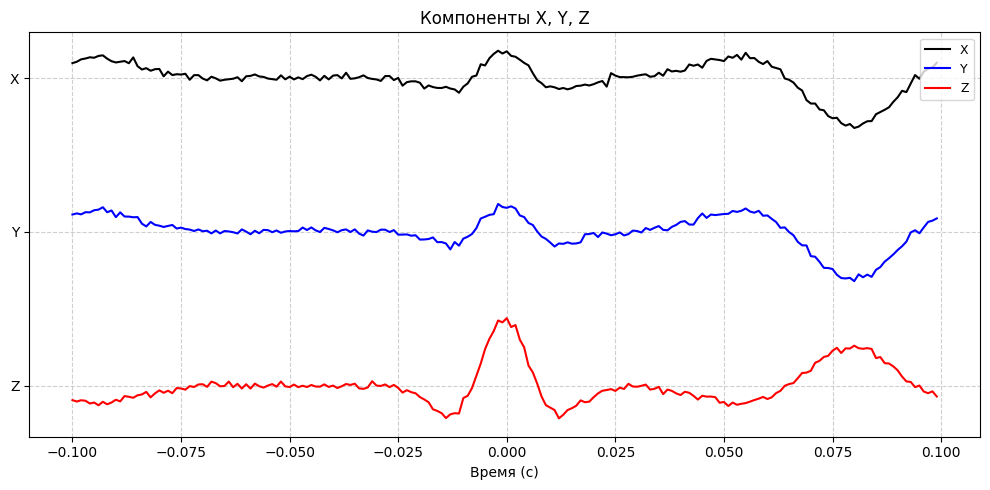

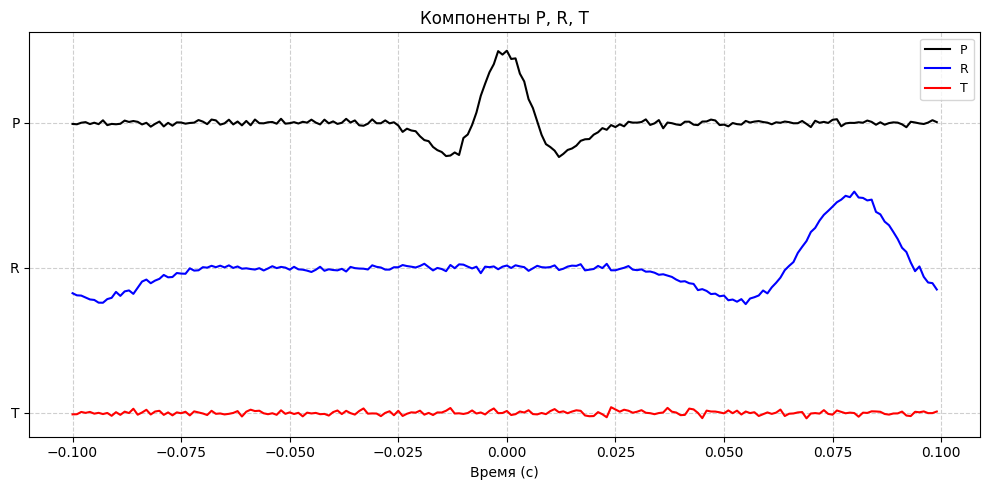

In [7]:
plot_analysis(t, x, y, z, names=['X', 'Y', 'Z'], title="Компоненты X, Y, Z")
plot_analysis(t, P, R, T, names=['P', 'R', 'T'], title="Компоненты P, R, T")

### 4. Анализ результатов.
Как видим, теперь:
* наша P-волна целиком на P-компоненте
* SV-волна на R-компоненте
* T-компонента содержит только шум (так как нет SH-волны). 


Что и требовалось по определению P, R, T